<a href="https://colab.research.google.com/github/7vika-lgtm/pneumonia_xray_cv/blob/main/pneumonia_xray_cv_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Detection from Chest X-rays: A Computer Vision Project
**Goal:** Train a convolutional neural network (CNN) to classify chest X-ray images as *normal* or *pneumonia*, then use **Grad-CAM** to see what the model is looking at.

**Research questions**
1. Can a small CNN trained from scratch detect pneumonia in X-rays?
2. How do we limit missed pneumonia cases (false negatives)?
3. Does the model focus on the lungs, or on irrelevant parts of the image?

**Dataset:** PneumoniaMNIST from MedMNIST v2 (pediatric chest X-rays, downsized to 64x64). It downloads automatically.

*Educational project only, not for clinical use.*

**Tip:** in Colab choose **Runtime → Change runtime type → T4 GPU** for faster training (CPU also works).

## 1. Setup

In [1]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.4 MB/s eta 0:00:00


In [2]:
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from medmnist import PneumoniaMNIST
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
import copy

torch.manual_seed(42); np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)
CLASSES = ["normal", "pneumonia"]
SIZE = 64

Using: cuda


## 2. Load the data
Training images get light augmentation (small rotations, shifts, zoom) so the model sees more variety. Validation and test images are left untouched.

In [3]:
norm = transforms.Normalize([0.5], [0.5])
train_tf = transforms.Compose([transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
                               transforms.ToTensor(), norm])
eval_tf = transforms.Compose([transforms.ToTensor(), norm])
to_int = lambda y: int(y[0])

train_ds = PneumoniaMNIST(split="train", download=True, size=SIZE, transform=train_tf, target_transform=to_int)
val_ds   = PneumoniaMNIST(split="val",   download=True, size=SIZE, transform=eval_tf,  target_transform=to_int)
test_ds  = PneumoniaMNIST(split="test",  download=True, size=SIZE, transform=eval_tf,  target_transform=to_int)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128)
test_loader  = DataLoader(test_ds, batch_size=128)
print("train / val / test sizes:", len(train_ds), len(val_ds), len(test_ds))

100%|██████████| 20.6M/20.6M [00:28<00:00, 732kB/s] 


train / val / test sizes: 4708 524 624


## 3. Explore the data

In [4]:
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    counts = np.bincount(ds.labels.ravel(), minlength=2)
    print(f"{name:5s} normal={counts[0]:4d}  pneumonia={counts[1]:4d}  ({counts[1]/counts.sum():.0%} pneumonia)")

train normal=1214  pneumonia=3494  (74% pneumonia)
val   normal= 135  pneumonia= 389  (74% pneumonia)
test  normal= 234  pneumonia= 390  (62% pneumonia)


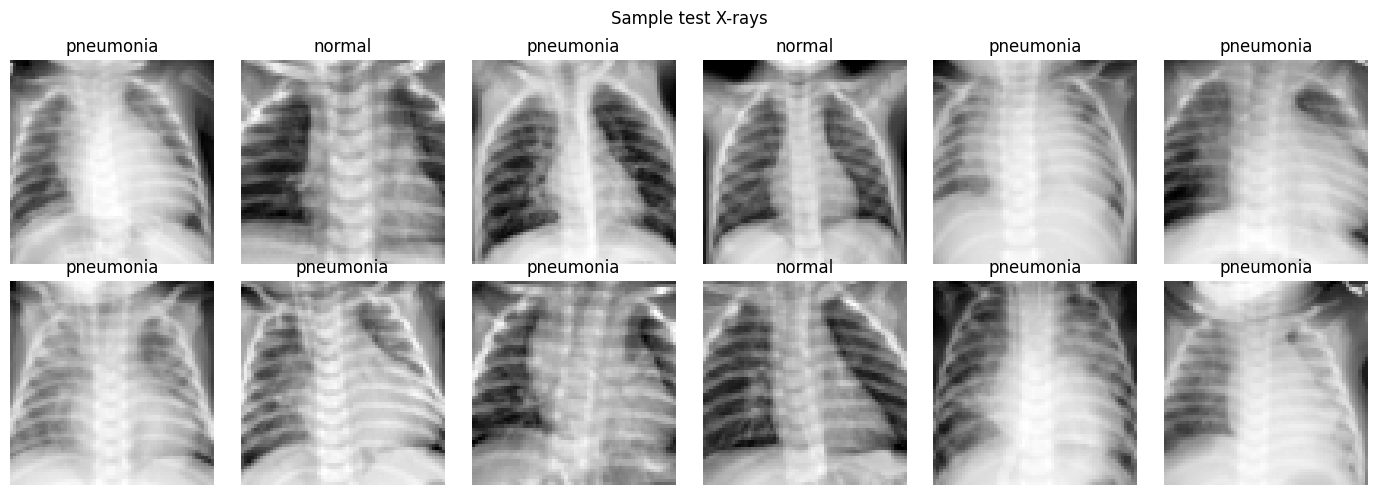

In [5]:
raw = PneumoniaMNIST(split="test", download=True, size=SIZE)   # untouched PIL images
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.ravel(), range(12)):
    img, lab = raw[i]
    ax.imshow(img, cmap="gray"); ax.set_title(CLASSES[int(lab[0])]); ax.axis("off")
plt.suptitle("Sample test X-rays"); plt.tight_layout(); plt.show()

**Observation:** the classes are imbalanced (pneumonia is the majority). If we ignore that, the model can score well by leaning toward "pneumonia". We handle it with **class weights** in the loss.

## 4. Build the CNN
Three convolution blocks (conv, batch norm, ReLU, pool), one extra conv layer, global average pooling and a small classifier. Keeping the last conv layer separate makes Grad-CAM easy later.

In [6]:
def block(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(block(1, 16), block(16, 32), block(32, 64),
                                      nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, 2))
    def forward(self, x):
        return self.head(self.features(x))

model = CNN().to(device)
print(sum(p.numel() for p in model.parameters()), "parameters")

60706 parameters


## 5. Train

In [7]:
counts = np.bincount(train_ds.labels.ravel(), minlength=2)
weights = torch.tensor(counts.sum() / (2 * counts), dtype=torch.float32).to(device)
crit = nn.CrossEntropyLoss(weight=weights)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, train):
    model.train(train)
    total, ys, ps = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            out = model(x)
            loss = crit(out, y)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(y)
        ys.append(y.cpu().numpy()); ps.append(out.softmax(1)[:, 1].detach().cpu().numpy())
    ys, ps = np.concatenate(ys), np.concatenate(ps)
    return total / len(ys), roc_auc_score(ys, ps), ys, ps

EPOCHS = 15
hist = {"tr_loss": [], "va_loss": [], "tr_auc": [], "va_auc": []}
best_auc, best_state = 0, None
for ep in range(1, EPOCHS + 1):
    tl, ta, _, _ = run_epoch(train_loader, True)
    vl, va, _, _ = run_epoch(val_loader, False)
    for k, v in zip(hist, [tl, vl, ta, va]): hist[k].append(v)
    if va > best_auc: best_auc, best_state = va, copy.deepcopy(model.state_dict())
    print(f"epoch {ep:2d} | train loss {tl:.3f} auc {ta:.3f} | val loss {vl:.3f} auc {va:.3f}")
model.load_state_dict(best_state)
print("Best validation AUC:", round(best_auc, 3))

epoch  1 | train loss 0.303 auc 0.950 | val loss 0.207 auc 0.976
epoch  2 | train loss 0.194 auc 0.978 | val loss 0.227 auc 0.977
epoch  3 | train loss 0.160 auc 0.985 | val loss 0.160 auc 0.985
epoch  4 | train loss 0.145 auc 0.987 | val loss 0.147 auc 0.987
epoch  5 | train loss 0.126 auc 0.990 | val loss 1.129 auc 0.979
epoch  6 | train loss 0.135 auc 0.988 | val loss 0.609 auc 0.988
epoch  7 | train loss 0.126 auc 0.990 | val loss 0.870 auc 0.992
epoch  8 | train loss 0.107 auc 0.992 | val loss 0.110 auc 0.993
epoch  9 | train loss 0.099 auc 0.994 | val loss 0.701 auc 0.992
epoch 10 | train loss 0.106 auc 0.993 | val loss 0.104 auc 0.995
epoch 11 | train loss 0.099 auc 0.993 | val loss 0.476 auc 0.994
epoch 12 | train loss 0.105 auc 0.993 | val loss 0.101 auc 0.995
epoch 13 | train loss 0.088 auc 0.995 | val loss 0.165 auc 0.996
epoch 14 | train loss 0.089 auc 0.995 | val loss 0.087 auc 0.995
epoch 15 | train loss 0.079 auc 0.996 | val loss 0.109 auc 0.995
Best validation AUC: 0.99

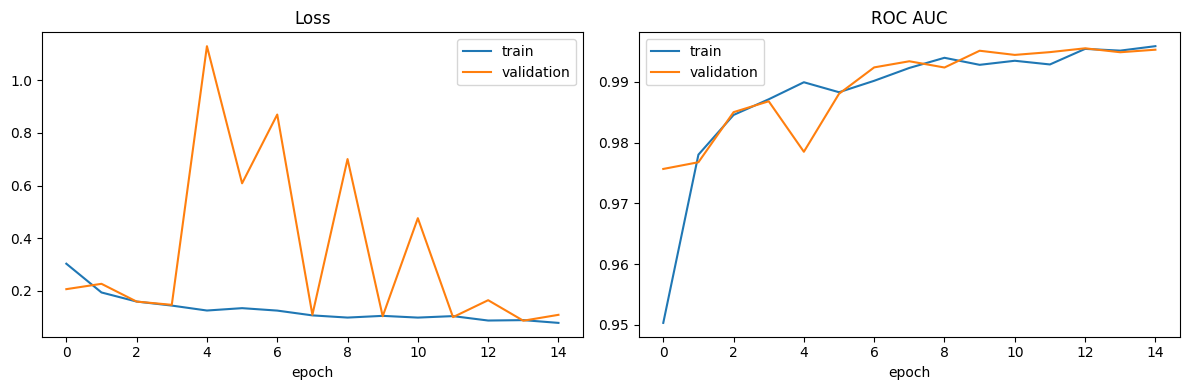

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["tr_loss"], label="train"); ax[0].plot(hist["va_loss"], label="validation"); ax[0].set_title("Loss")
ax[1].plot(hist["tr_auc"], label="train"); ax[1].plot(hist["va_auc"], label="validation"); ax[1].set_title("ROC AUC")
for a in ax: a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

A large gap between training and validation curves means **overfitting**. If you see it, try more augmentation, a higher dropout value or fewer epochs.

## 6. Evaluate on the test set

              precision    recall  f1-score   support

      normal       1.00      0.56      0.71       234
   pneumonia       0.79      1.00      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.87      0.83      0.82       624

Test ROC AUC: 0.979


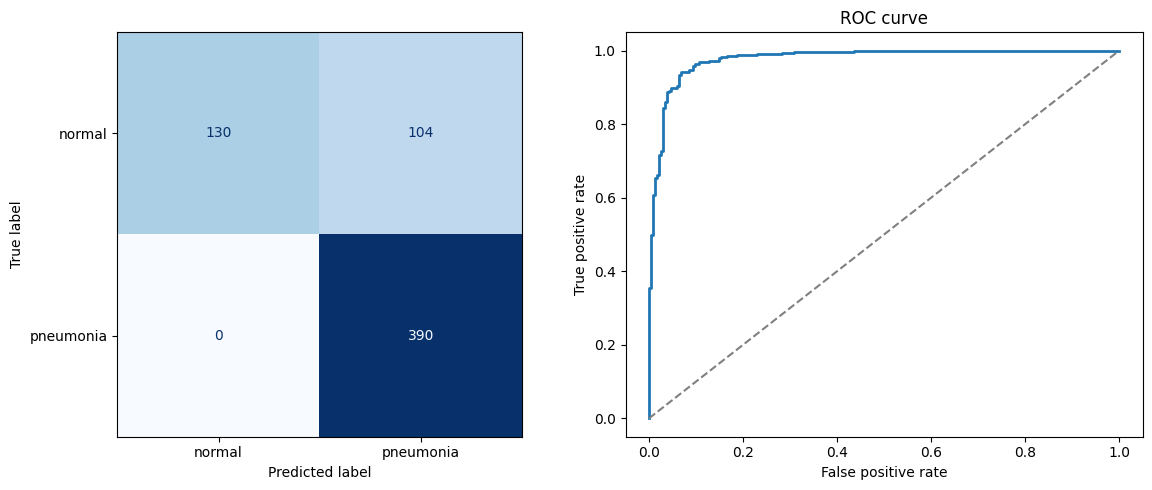

In [9]:
_, test_auc, y_true, y_prob = run_epoch(test_loader, False)
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_true, y_pred, target_names=CLASSES))
print("Test ROC AUC:", round(test_auc, 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(ax=ax[0], cmap="Blues", colorbar=False)
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax[1].plot(fpr, tpr, lw=2); ax[1].plot([0, 1], [0, 1], "--", c="gray")
ax[1].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
plt.tight_layout(); plt.show()

## 7. Threshold analysis (limiting missed pneumonia)

In [10]:
for t in [0.5, 0.4, 0.3, 0.2]:
    p = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, p).ravel()
    print(f"threshold {t}: missed pneumonia (FN)={fn:3d} | false alarms (FP)={fp:3d} | recall={tp/(tp+fn):.2f} | specificity={tn/(tn+fp):.2f}")

threshold 0.5: missed pneumonia (FN)=  0 | false alarms (FP)=104 | recall=1.00 | specificity=0.56
threshold 0.4: missed pneumonia (FN)=  0 | false alarms (FP)=119 | recall=1.00 | specificity=0.49
threshold 0.3: missed pneumonia (FN)=  0 | false alarms (FP)=132 | recall=1.00 | specificity=0.44
threshold 0.2: missed pneumonia (FN)=  0 | false alarms (FP)=147 | recall=1.00 | specificity=0.37


## 8. Explainability with Grad-CAM
Grad-CAM highlights the image regions that pushed the model toward its prediction. Red/yellow means more influence.

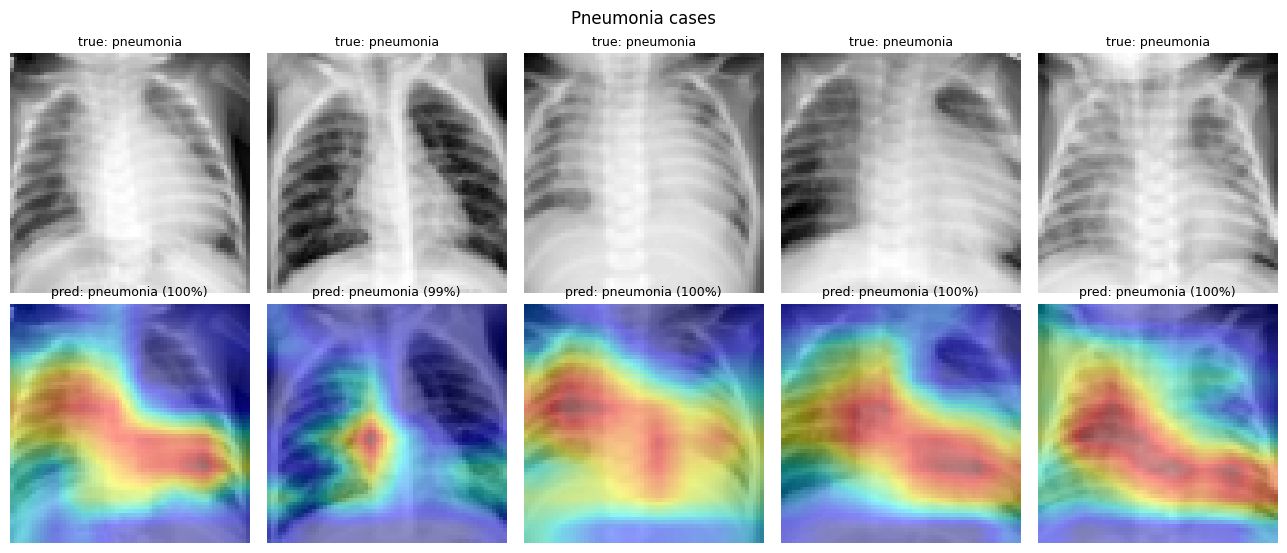

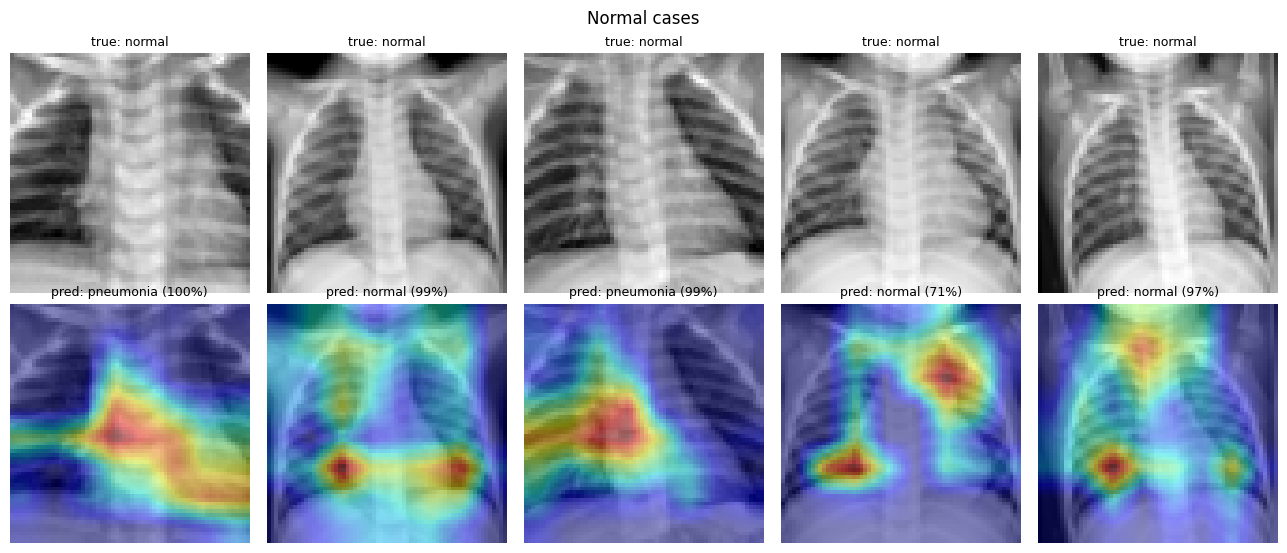

In [11]:
def gradcam(x, cls=None):
    model.eval()
    x = x.unsqueeze(0).to(device)
    feats = model.features(x)
    feats.retain_grad()
    out = model.head(feats)
    c = out.argmax(1).item() if cls is None else cls
    model.zero_grad()
    out[0, c].backward()
    w = feats.grad.mean((2, 3), keepdim=True)
    cam = F.relu((w * feats).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy(), out.softmax(1)[0].detach().cpu().numpy()

def show_cams(indices, title):
    fig, axes = plt.subplots(2, len(indices), figsize=(2.6 * len(indices), 5.6))
    for j, i in enumerate(indices):
        x, y = test_ds[i]
        cam, prob = gradcam(x)
        img = (x[0].numpy() * 0.5 + 0.5)
        axes[0, j].imshow(img, cmap="gray"); axes[0, j].axis("off")
        axes[0, j].set_title(f"true: {CLASSES[y]}", fontsize=9)
        axes[1, j].imshow(img, cmap="gray"); axes[1, j].imshow(cam, cmap="jet", alpha=0.45); axes[1, j].axis("off")
        axes[1, j].set_title(f"pred: {CLASSES[prob.argmax()]} ({prob.max():.0%})", fontsize=9)
    plt.suptitle(title); plt.tight_layout(); plt.show()

pneu_idx = np.where(y_true == 1)[0][:5]
norm_idx = np.where(y_true == 0)[0][:5]
show_cams(pneu_idx, "Pneumonia cases")
show_cams(norm_idx, "Normal cases")

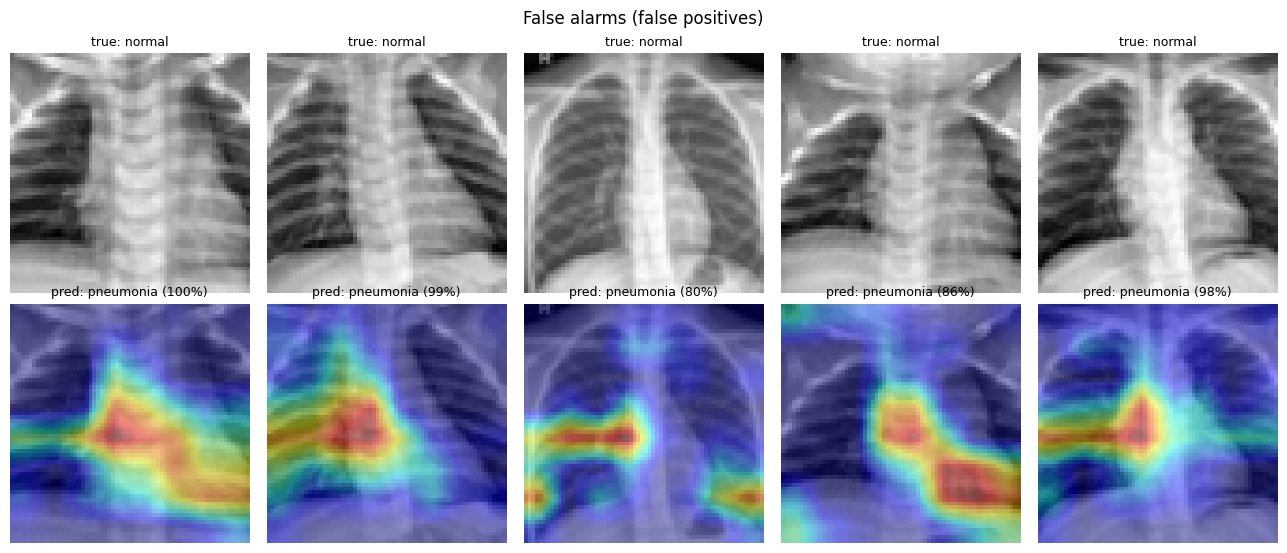

In [12]:
# Look at the model's mistakes, starting with missed pneumonia
missed = np.where((y_true == 1) & (y_pred == 0))[0][:5]
false_alarm = np.where((y_true == 0) & (y_pred == 1))[0][:5]
if len(missed): show_cams(missed, "Missed pneumonia (false negatives)")
if len(false_alarm): show_cams(false_alarm, "False alarms (false positives)")

**Check:** does the heat fall over the lungs, or on the image border, text markers or the heart? If it often highlights non-lung areas, the model may be using shortcuts instead of real signs of disease.

## 9. Conclusions & limitations
- Write your findings here using the numbers above: test recall, specificity, AUC, and what Grad-CAM showed.
- **Limitations:** images are tiny (64x64), the data comes from one hospital's pediatric patients, the test set has a different class balance from the training set, and there is no external validation.
- **Ethics:** a model that works on one hospital's scanners can fail on another's. Any real use needs clinician oversight and proper validation.

## Next steps
- Try `size=128` or `224` images (change `SIZE` at the top).
- Use **transfer learning** with a pretrained ResNet18 from `torchvision`.
- Try other MedMNIST datasets such as `DermaMNIST` (skin lesions) or `BloodMNIST`.
- Add confidence calibration and test on a second dataset.

## References
- Yang et al., *MedMNIST v2: A large-scale lightweight benchmark for 2D and 3D biomedical image classification*, Scientific Data (2023).
- Kermany et al., *Identifying medical diagnoses and treatable diseases by image-based deep learning*, Cell (2018).
- Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks* (2017).